In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
from adjustText import adjust_text

In [5]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [6]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [7]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].dropna(subset='salary_year_avg')

In [8]:
df_DA_US_exploded = df_DA_US.explode('job_skills')


In [9]:
job_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending= False)
job_count = len(df_DA_US)
job_skills['skill percentage'] = job_skills['count']/job_count* 100
job_skills = job_skills[job_skills['skill percentage']>0]
job_skills

,count,median,skill percentage
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
couchbase,1,160515.0,0.022989
chainer,1,100000.0,0.022989
chef,1,85000.0,0.022989


In [10]:
skill_limit = 5
df_DA_skill_high_demand = job_skills[job_skills['skill percentage']>skill_limit]
df_DA_skill_high_demand

,count,median,skill percentage
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


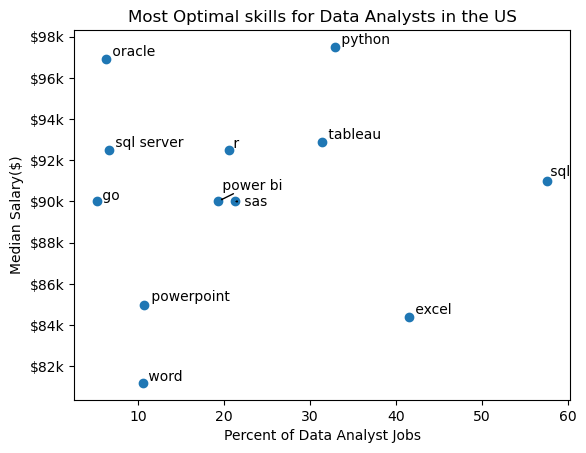

In [13]:
plt.scatter(df_DA_skill_high_demand['skill percentage'], df_DA_skill_high_demand['median'])
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary($)')
plt.title('Most Optimal skills for Data Analysts in the US')
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}k'))
texts=[]
for i,txt in enumerate(df_DA_skill_high_demand.index):
    texts.append(plt.text(df_DA_skill_high_demand['skill percentage'].iloc[i], df_DA_skill_high_demand['median'].iloc[i], " " + txt))
adjust_text(texts,arrowprops=dict(arrowstyle='->'))
plt.show()